# L5 – Técnicas de reducción dimensional con dataset Wine

En este notebook aplicamos y comparamos PCA y t-SNE sobre el dataset **Wine** (13 variables numéricas):

1. Análisis exploratorio inicial.
2. Escalado con StandardScaler.
3. PCA a 2 componentes + visualización 2D.
4. t-SNE a 2 dimensiones + visualización 2D.
5. Plus: probar distintos parámetros de t-SNE.


In [1]:
# Paso 1: Importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_wine

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42

## 1. Cargar el dataset Wine

Cargamos el dataset Wine de `sklearn`, que contiene 13 variables numéricas por vino y una etiqueta de clase (tipo de vino).

In [2]:
# Paso 2: Cargar datos (Wine)

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)  # solo variables numéricas
y = data.target  # clases verdaderas (solo para colorear los gráficos)

print('Dimensiones de X:', X.shape)
X.head()

Dimensiones de X: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 2. Análisis exploratorio inicial

Revisamos tipos de datos, valores nulos y estadísticos descriptivos básicos.

In [4]:
# 3.1 Información general y nulos

print('Información del dataframe:')
print(X.info())
print('Total de valores nulos:', X.isnull().sum().sum())

Información del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non

In [5]:
# 3.2 Estadísticos descriptivos

X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


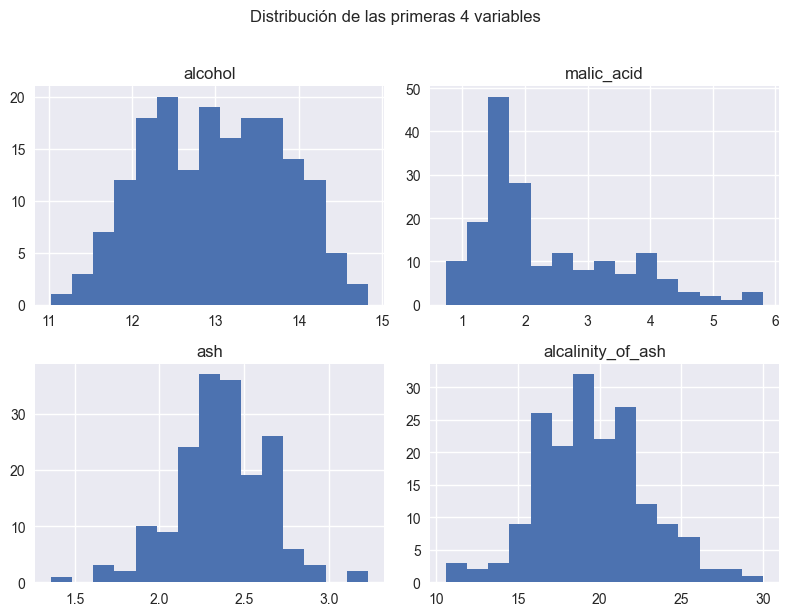

In [6]:
# 3.3 Histogramas de las primeras 4 variables

X.iloc[:, :4].hist(figsize=(8, 6), bins=15)
plt.suptitle('Distribución de las primeras 4 variables', y=1.02)
plt.tight_layout()
plt.show()

## 3. Escalado de variables

Aplicamos `StandardScaler` para que cada variable tenga media 0 y desvío estándar 1. Esto es importante porque PCA y t-SNE dependen de las distancias y la varianza de las variables.

In [7]:
# Paso 3: Escalar los datos

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Forma de X_scaled:', X_scaled.shape)
print('Media aprox (primeras 5 columnas):', X_scaled[:, :5].mean(axis=0))
print('Desvío aprox (primeras 5 columnas):', X_scaled[:, :5].std(axis=0))

Forma de X_scaled: (178, 13)
Media aprox (primeras 5 columnas): [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17]
Desvío aprox (primeras 5 columnas): [1. 1. 1. 1. 1.]


## 4. PCA: reducción a 2 componentes y visualización 2D

PCA busca nuevas variables (componentes principales) que sean combinaciones lineales de las originales y que expliquen la mayor varianza posible.

In [8]:
# Paso 4: Aplicar PCA (2 componentes)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print('Forma de la proyección PCA:', X_pca.shape)
print('Varianza explicada por cada componente:', pca.explained_variance_ratio_)
print('Varianza total explicada (2 componentes):', pca.explained_variance_ratio_.sum())

Forma de la proyección PCA: (178, 2)
Varianza explicada por cada componente: [0.36198848 0.1920749 ]
Varianza total explicada (2 componentes): 0.5540633835693526


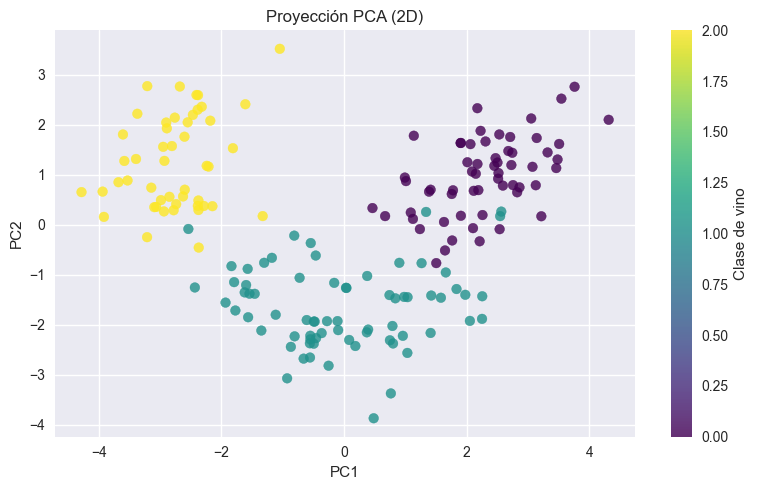

In [9]:
# Visualizar PCA 2D

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.8
)
plt.title('Proyección PCA (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
cbar = plt.colorbar(scatter)
cbar.set_label('Clase de vino')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. t-SNE: proyección no lineal a 2D

t-SNE preserva principalmente las relaciones de vecindad (puntos cercanos siguen cerca en la proyección 2D).

In [10]:
# Paso 5: Aplicar t-SNE (configuración base)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=RANDOM_STATE,
    init='pca'
)

X_tsne = tsne.fit_transform(X_scaled)

print('Forma de la proyección t-SNE:', X_tsne.shape)

Forma de la proyección t-SNE: (178, 2)


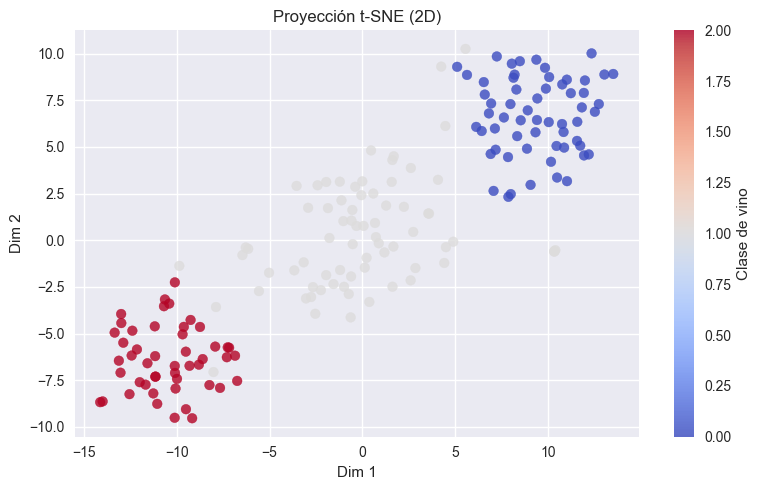

In [11]:
# Visualizar t-SNE 2D

plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.8
)
plt.title('Proyección t-SNE (2D)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
cbar = plt.colorbar(scatter)
cbar.set_label('Clase de vino')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Plus: efecto de distintos parámetros en t-SNE

Probamos diferentes combinaciones de `perplexity` y `learning_rate` para ver cómo cambia la forma de los clústers en la proyección.


C:\Users\yuri1\AppData\Local\Temp\ipykernel_31060\1689327903.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


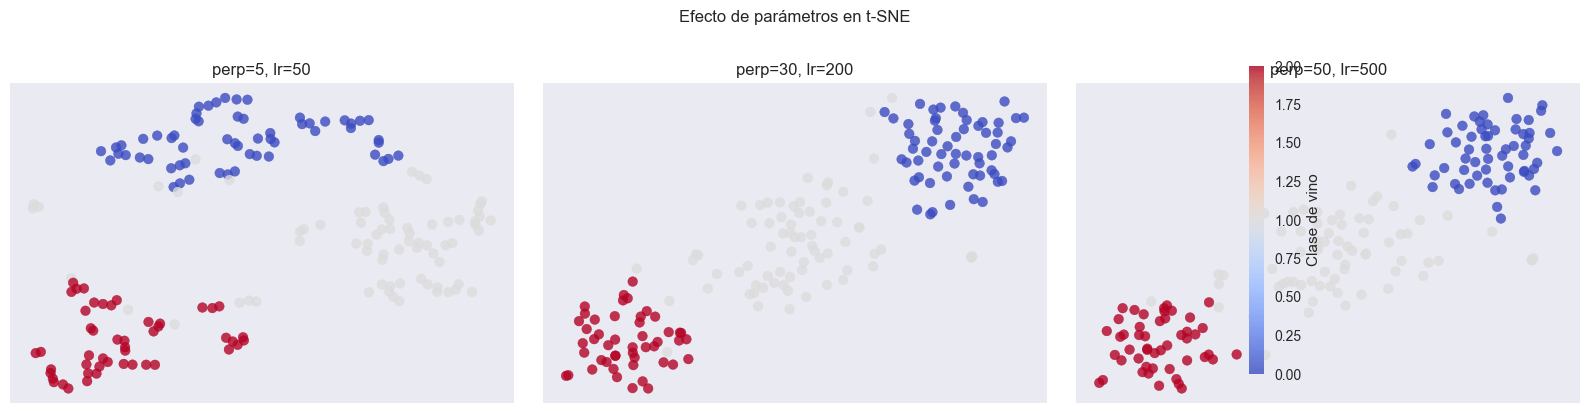

In [12]:
# Plus: probar otros parámetros de t-SNE

configs = [
    {'perplexity': 5, 'learning_rate': 50},
    {'perplexity': 30, 'learning_rate': 200},
    {'perplexity': 50, 'learning_rate': 500},
]

fig, axes = plt.subplots(1, len(configs), figsize=(16, 4))

for ax, cfg in zip(axes, configs):
    tsne_cfg = TSNE(
        n_components=2,
        perplexity=cfg['perplexity'],
        learning_rate=cfg['learning_rate'],
        random_state=RANDOM_STATE,
        init='pca'
    )
    X_tsne_cfg = tsne_cfg.fit_transform(X_scaled)
    sc = ax.scatter(
        X_tsne_cfg[:, 0],
        X_tsne_cfg[:, 1],
        c=y,
        cmap='coolwarm',
        alpha=0.8
    )
    ax.set_title(f"perp={cfg['perplexity']}, lr={cfg['learning_rate']}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, ax=axes, label='Clase de vino')
plt.suptitle('Efecto de parámetros en t-SNE', y=1.02)
plt.tight_layout()
plt.show()

## 7. Comparación y reflexión

- **PCA** conserva bien la estructura global y la varianza, pero es una proyección lineal, por lo que puede mostrar algo de solapamiento entre clases.
- **t-SNE** suele separar mejor los grupos de vinos en “islas” bien definidas, ideal para mostrar visualmente la existencia de clústers, aunque sus ejes no son directamente interpretables.

En el contexto del dataset Wine, una buena estrategia es usar PCA para entender qué variables contribuyen más a cada componente y t-SNE para una visualización clara de los grupos de vinos.
